# HW3 Applied: Zero-Shot Super Resolution (ZSSR)

**Course:** Modern Computer Vision (Technion, Spring 2026)

**Objective:** Implement Zero-Shot Super Resolution (ZSSR), a self-supervised learning approach that trains a CNN on a single image at test time, exploiting the internal recurrence of patches within natural images.

**Before you start**, read the paper:

> Shocher et al., ["Zero-Shot Super-Resolution using Deep Internal Learning"](https://openaccess.thecvf.com/content_cvpr_2018/papers/Shocher_Zero-Shot_Super-Resolution_Using_CVPR_2018_paper.pdf) (CVPR 2018)
>
> Project page: [http://www.wisdom.weizmann.ac.il/~vision/zssr/](http://www.wisdom.weizmann.ac.il/~vision/zssr/)

## Submission Requirements

**IMPORTANT:** Submit this notebook **with all outputs** (cell outputs, training curves, visualizations). Notebooks without outputs will lose points.

In [1]:
# Setup and imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import math
import io, base64
from typing import Tuple, Optional
from PIL import Image as PILImage
from IPython.display import display, HTML
from resize_right import resize as resize_right_resize
from resize_right.interp_methods import cubic as cubic_interp
import warnings
warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

Using device: cpu


## Utility Functions


In [2]:
def psnr(img1, img2):
    """
    Calculate PSNR between two images. Both must be in [0, 1] range.
    Handles torch tensors and numpy arrays, any shape.
    """
    if isinstance(img1, torch.Tensor):
        img1 = img1.detach().cpu().float().numpy()
    if isinstance(img2, torch.Tensor):
        img2 = img2.detach().cpu().float().numpy()
    img1 = np.clip(img1.astype(np.float64), 0, 1)
    img2 = np.clip(img2.astype(np.float64), 0, 1)
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20 * np.log10(1.0 / np.sqrt(mse))


def resize_bicubic(image_tensor, scale_factor=None, size=None):
    """Resize using resize_right for correct pixel alignment (no half-pixel shift).
    
    Handles 2D (H,W), 3D (C,H,W), and 4D (B,C,H,W) inputs.
    """
    ndim = image_tensor.dim()
    if ndim == 2:
        image_tensor = image_tensor.unsqueeze(0).unsqueeze(0)
    elif ndim == 3:
        image_tensor = image_tensor.unsqueeze(0)
    if scale_factor is not None:
        scale_factors = [1, 1, scale_factor, scale_factor]
        resized = resize_right_resize(image_tensor, scale_factors=scale_factors,
                                       interp_method=cubic_interp,
                                       antialiasing=(scale_factor < 1))
    elif size is not None:
        if isinstance(size, int):
            size = (size, size)
        out_shape = [image_tensor.shape[0], image_tensor.shape[1], size[0], size[1]]
        resized = resize_right_resize(image_tensor, out_shape=out_shape,
                                       interp_method=cubic_interp,
                                       antialiasing=True)
    else:
        raise ValueError("Must provide either scale_factor or size")
    if ndim == 2:
        return resized.squeeze(0).squeeze(0)
    elif ndim == 3:
        return resized.squeeze(0)
    return resized


def load_test_images():
    from skimage import data as skdata
    images = {}
    hubble = skdata.hubble_deep_field().astype(np.float32) / 255.0
    hubble = hubble[:868, :1000, :]  # dims divisible by 4
    images['Hubble Deep Field'] = torch.from_numpy(hubble).permute(2, 0, 1)
    rocket = skdata.rocket().astype(np.float32) / 255.0
    rocket = rocket[:424, :640, :]
    images['Rocket'] = torch.from_numpy(rocket).permute(2, 0, 1)
    return images


def _to_display(img):
    """Convert image tensor/array to (H, W, C) numpy for display."""
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().float().numpy()
    img = np.clip(img, 0, 1)
    if img.ndim == 2:
        return np.stack([img]*3, axis=-1)
    if img.ndim == 3 and img.shape[0] in (1, 3):
        img = np.transpose(img, (1, 2, 0))
    if img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    return img


def make_flickering_gif(img_a, img_b, label_a, label_b, duration=800):
    """Create a flickering GIF between two images, returned as HTML for display."""
    frames = []
    for arr, label in [(img_a, label_a), (img_b, label_b)]:
        arr_disp = _to_display(arr)
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        ax.imshow(arr_disp)
        ax.set_title(label, fontsize=16, fontweight='bold', pad=8)
        ax.axis('off')
        fig.tight_layout()
        buf = io.BytesIO()
        fig.savefig(buf, format='png', dpi=100, bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        frames.append(PILImage.open(buf).convert('RGB'))

    gif_buf = io.BytesIO()
    frames[0].save(gif_buf, format='GIF', append_images=frames[1:],
                   save_all=True, duration=duration, loop=0)
    gif_buf.seek(0)
    gif_b64 = base64.b64encode(gif_buf.read()).decode()
    return f'<img src="data:image/gif;base64,{gif_b64}" style="max-width:100%;"/>'


def visualize_results(results, title=""):
    """
    Visualize SR results as full-size flickering comparison.
    Shows: flickering GIF (Bicubic ↔ ZSSR) + ground truth alongside.
    """
    psnr_bic = results['PSNR_Bicubic']
    psnr_zssr = results['PSNR_ZSSR']

    # Full-size flickering: Bicubic vs ZSSR
    gif_html = make_flickering_gif(
        results['Bicubic'], results['ZSSR'],
        f'Bicubic ({psnr_bic:.2f} dB)', f'ZSSR ({psnr_zssr:.2f} dB)')

    # Ground truth
    gt_disp = _to_display(results['HR'])
    fig_gt, ax_gt = plt.subplots(1, 1, figsize=(6, 6))
    ax_gt.imshow(gt_disp)
    ax_gt.set_title('Ground Truth (HR)', fontsize=16, fontweight='bold')
    ax_gt.axis('off')
    fig_gt.tight_layout()
    buf_gt = io.BytesIO()
    fig_gt.savefig(buf_gt, format='png', dpi=100, bbox_inches='tight')
    plt.close(fig_gt)
    buf_gt.seek(0)
    gt_b64 = base64.b64encode(buf_gt.read()).decode()

    html = f'''
    <h3>{title} — PSNR improvement: {psnr_zssr - psnr_bic:+.2f} dB</h3>
    <div style="display:flex; align-items:flex-start; gap:20px; flex-wrap:wrap;">
      <div>{gif_html}</div>
      <div><img src="data:image/png;base64,{gt_b64}" style="max-width:100%;"/></div>
    </div>
    '''
    display(HTML(html))

# Part 1: Understanding ZSSR

## The ZSSR Concept

### Training Phase
Given a low-resolution image **I_LR**:
1. **Downscale** I_LR by a factor (e.g., 2) to get **I_LR_downscaled**
2. Train a CNN to map: **I_LR_downscaled** → **I_LR**
3. The model learns to "upscale" this degraded version back to the original

### Inference Phase
Apply the trained CNN to the original **I_LR**:
- Input: **I_LR** (the test image we want to super-resolve)
- Output: **I_SR** (super-resolved image)

### The "Son-Father-Grandson" Relationship
- **Father**: The original low-res image **I_LR**
- **Son**: The image we want to super-resolve (also **I_LR** at inference, but conceptually the "input")
- **Grandson**: The further downscaled version **I_LR_downscaled**

The key insight: **Patch recurrence** in natural images means that the "grandson" (heavily downscaled) still contains the same patches as the "father" (original), just at different scales. The CNN learns to exploit this self-similarity.

# Part 2: Basic ZSSR Model (15 pts)

Implement a simple CNN-based architecture that:
1. Takes a low-res image and a scale factor as input
2. Bicubically upsamples to the target high-res size
3. Refines the upsampled image using convolutional layers
4. Uses a residual connection (learn the residual, not the full image)


In [3]:
class ZSSRNet(nn.Module):
    def __init__(self, in_channels=3, n_channels=64, n_layers=8, kernel_size=3):
        super().__init__()
        self.layers = nn.ModuleList()
        p = kernel_size // 2
        self.layers.append(nn.Conv2d(in_channels, n_channels, kernel_size, padding=p))
        for _ in range(n_layers - 2):
            self.layers.append(nn.Conv2d(n_channels, n_channels, kernel_size, padding=p))
        self.layers.append(nn.Conv2d(n_channels, in_channels, kernel_size, padding=p))
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x, scale_factor=2, target_size=None):
        sq = x.dim() == 3
        if sq: x = x.unsqueeze(0)
        if target_size is None:
            target_size = (x.shape[-2]*scale_factor, x.shape[-1]*scale_factor)
        up = resize_bicubic(x, size=target_size)
        res = up.clone()
        o = up
        for i, layer in enumerate(self.layers):
            o = layer(o)
            if i < len(self.layers)-1: o = self.relu(o)
        o = o + res
        return o.squeeze(0) if sq else o

# Part 3: Dataset (10 pts)

Implement a dataset class that:
1. Takes a single image
2. Generates pairs of (HR, LR) where LR is a downscaled version of HR
3. Applies random crops for training diversity


In [4]:
class ZSSRDataset(Dataset):
    def __init__(self, image, scale_factor=2, crop_size=64, n_samples=100, augment=False):
        self.image, self.scale_factor = image, scale_factor
        self.crop_size, self.n_samples, self.augment = crop_size, n_samples, augment
    def __len__(self): return self.n_samples
    def _aug8(self, img):
        a = []
        for k in range(4):
            r = torch.rot90(img, k=k, dims=[-2,-1])
            a.extend([r, torch.flip(r, dims=[-1])])
        return a
    def __getitem__(self, idx):
        h, w = self.image.shape[-2], self.image.shape[-1]
        ch, cw = min(self.crop_size, h), min(self.crop_size, w)
        t, l = np.random.randint(0, max(1,h-ch+1)), np.random.randint(0, max(1,w-cw+1))
        hr = self.image[:, t:t+ch, l:l+cw]
        lr = resize_bicubic(hr, scale_factor=1.0/self.scale_factor)
        if self.augment:
            return {'HR': torch.stack(self._aug8(hr)), 'LR': torch.stack(self._aug8(lr))}
        return {'HR': hr, 'LR': lr}

# Part 4: Training Loop (15 pts)

Implement the training function with:
1. L1 loss (or MSE)
2. Adam optimizer with learning rate scheduling
3. PSNR logging during training
4. Progress tracking


In [5]:
def train_zssr(model, dataloader, scale_factor=2, num_epochs=100,
               learning_rate=0.001, device='cpu', verbose=True):
    model = model.to(device)
    crit = nn.L1Loss()
    opt = Adam(model.parameters(), lr=learning_rate)
    sched = StepLR(opt, step_size=50, gamma=0.5)
    lh, ph = [], []
    model.train()
    for ep in range(num_epochs):
        el, ep2, nb2 = 0., 0., 0
        for batch in dataloader:
            hr, lr = batch['HR'].to(device), batch['LR'].to(device)
            if hr.dim() == 5:
                B,A,C,h,w = hr.shape
                hr = hr.view(B*A,C,h,w); lr = lr.view(B*A,C,lr.shape[-2],lr.shape[-1])
            opt.zero_grad()
            sr = model(lr, scale_factor=scale_factor, target_size=(hr.shape[-2],hr.shape[-1]))
            if sr.shape != hr.shape: sr = resize_bicubic(sr, size=(hr.shape[-2],hr.shape[-1]))
            loss = crit(sr, hr); loss.backward(); opt.step()
            with torch.no_grad(): ep2 += psnr(torch.clamp(sr,0,1), hr)
            el += loss.item(); nb2 += 1
        sched.step()
        lh.append(el/nb2); ph.append(ep2/nb2)
        if verbose and (ep+1)%10==0: print(f"Epoch {ep+1}/{num_epochs} | Loss: {el/nb2:.6f} | PSNR: {ep2/nb2:.2f} dB")
    return model, lh, ph

# Part 5: Evaluation (10 pts + up to 25 pts PSNR bonus)

Evaluate the model by:
1. Computing PSNR against ground truth
2. Comparing with bicubic baseline
3. Visualizing results

### PSNR Scoring

Your ZSSR **must** beat the bicubic baseline (10 pts). Beyond that, bonus points are awarded based on PSNR improvement $p$ (in dB) over bicubic, using the formula:

$$\text{bonus} = \left\lfloor \frac{p^{2.5}}{5} \right\rfloor \quad \text{(capped at 25 pts)}$$

| Improvement (dB) | Bonus |
|:-:|:-:|
| 0 | 0 |
| 1 | 0 |
| 2 | 1 |
| 3 | 3 |
| 4 | 6 |
| 5 | 11 |
| 6+ | 17–25 |

A good implementation typically achieves 2–4 dB improvement.

In [6]:
def evaluate_zssr(model, image_hr, scale_factor=2, device='cpu', title=""):
    model.to(device); model.eval()
    with torch.no_grad():
        lr = resize_bicubic(image_hr, scale_factor=1.0/scale_factor)
        bic = resize_bicubic(lr, size=(image_hr.shape[-2], image_hr.shape[-1]))
        sr = model(lr.unsqueeze(0).to(device), scale_factor=scale_factor,
                   target_size=(image_hr.shape[-2], image_hr.shape[-1])).squeeze(0)
        sr = torch.clamp(sr, 0, 1); bic = torch.clamp(bic, 0, 1)
        return {'HR': image_hr.cpu(), 'LR': lr.cpu(), 'Bicubic': bic.cpu(), 'ZSSR': sr.cpu(),
                'PSNR_Bicubic': psnr(bic, image_hr), 'PSNR_ZSSR': psnr(sr, image_hr)}

# Part 6: Data Augmentation — Advanced (15 pts bonus / required for full marks)

Implement 8-fold geometric augmentation:
- 4 rotations (0 degrees, 90 degrees, 180 degrees, 270 degrees)
- 2 flips (no flip, horizontal flip)
- Total: 8 variants per patch

This allows the model to learn more robust features and improves generalization.


In [7]:
def ensemble_predict_zssr(model, image_lr, scale_factor=2, device='cpu'):
    model.eval(); dev = next(model.parameters()).device
    augs = []
    for k in range(4):
        r = torch.rot90(image_lr, k=k, dims=[-2,-1])
        augs.extend([r, torch.flip(r, dims=[-1])])
    preds = []
    with torch.no_grad():
        for aug in augs:
            sr = model(aug.unsqueeze(0).to(dev), scale_factor=scale_factor).squeeze(0)
            sr = torch.clamp(sr, 0, 1)
            idx = len(preds)
            if idx % 2 == 1: sr = torch.flip(sr, dims=[-1])
            kv = (idx//2) % 4
            if kv > 0: sr = torch.rot90(sr, k=4-kv, dims=[-2,-1])
            preds.append(sr.cpu())
    return torch.stack(preds).mean(0)

# Part 7: Visualization & Analysis (15 pts)

Visualize your results:
1. Plot training curves (loss and PSNR)
2. Compare ZSSR vs bicubic visually
3. Show side-by-side comparisons

In [8]:
def plot_training_curves(loss_history, psnr_history, figsize=(14, 5)):
    """
    Plot training loss and PSNR curves.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Loss curve
    ax1.plot(loss_history, linewidth=2, label='Training Loss')
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Loss (L1)', fontsize=11)
    ax1.set_title('Training Loss Over Time', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # PSNR curve
    ax2.plot(psnr_history, linewidth=2, color='green', label='Training PSNR')
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('PSNR (dB)', fontsize=11)
    ax2.set_title('PSNR Over Time', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    return fig


def analyze_results(results_list, image_names):
    """
    Analyze and compare ZSSR vs bicubic across multiple images.
    
    Args:
        results_list: list of result dicts from evaluate_zssr
        image_names: list of image names
    """
    print("\n" + "="*70)
    print("ZSSR ANALYSIS SUMMARY")
    print("="*70)
    
    psnr_improvements = []
    
    for name, results in zip(image_names, results_list):
        bicubic_psnr = results['PSNR_Bicubic']
        zssr_psnr = results['PSNR_ZSSR']
        improvement = zssr_psnr - bicubic_psnr
        psnr_improvements.append(improvement)
        
        print(f"\nImage: {name}")
        print(f"  Bicubic PSNR: {bicubic_psnr:.3f} dB")
        print(f"  ZSSR PSNR:    {zssr_psnr:.3f} dB")
        print(f"  Improvement:  {improvement:+.3f} dB")
    
    avg_improvement = np.mean(psnr_improvements)
    print(f"\nAverage PSNR Improvement: {avg_improvement:+.3f} dB")
    print("="*70)
    
    return psnr_improvements


# Part 8: Main Experiment\n\nLet's run the complete ZSSR pipeline on test images.

Loading test images...
Loaded 2 images:
  Hubble Deep Field: torch.Size([3, 868, 1000])
  Rocket: torch.Size([3, 424, 640])


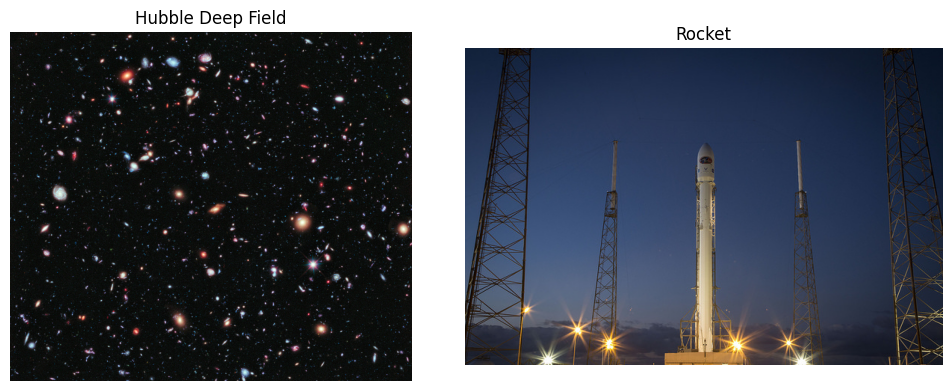

In [9]:
# Load test images
print("Loading test images...")
test_images = load_test_images()
image_names = list(test_images.keys())

print(f"Loaded {len(test_images)} images:")
for name, img in test_images.items():
    print(f"  {name}: {img.shape}")

# Visualize
fig, axes = plt.subplots(1, len(test_images), figsize=(5 * len(test_images), 4))
if len(test_images) == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, test_images.items()):
    ax.imshow(_to_display(img))
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Training on Image 1

In [10]:
# Prepare data for first image
scale_factor = 4
img_name_1 = image_names[0]
test_image_1 = test_images[img_name_1]

dataset_1 = ZSSRDataset(
    test_image_1,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,
    augment=False
)

dataloader_1 = DataLoader(dataset_1, batch_size=4, shuffle=True)

# Initialize model (3 channels for RGB)
model_1 = ZSSRNet(in_channels=3, n_channels=64, n_layers=8)
print(f"Model parameters: {sum(p.numel() for p in model_1.parameters()):,}")

# Train
print(f"\nTraining ZSSR on {img_name_1}...")
model_1, loss_hist_1, psnr_hist_1 = train_zssr(
    model_1,
    dataloader_1,
    scale_factor=scale_factor,
    num_epochs=100,
    learning_rate=0.001,
    device=device,
    verbose=True
)

print("\nTraining complete!")

Model parameters: 225,091

Training ZSSR on Hubble Deep Field...


Epoch 10/100 | Loss: 0.021016 | PSNR: 29.03 dB


Epoch 20/100 | Loss: 0.020453 | PSNR: 29.52 dB


Epoch 30/100 | Loss: 0.020219 | PSNR: 29.71 dB


Epoch 40/100 | Loss: 0.020129 | PSNR: 29.72 dB


...

Epoch 60/100 | Loss: 0.019620 | PSNR: 30.11 dB


Epoch 70/100 | Loss: 0.019466 | PSNR: 30.17 dB


Epoch 80/100 | Loss: 0.020131 | PSNR: 29.86 dB


Epoch 90/100 | Loss: 0.019434 | PSNR: 30.18 dB


Epoch 100/100 | Loss: 0.019410 | PSNR: 30.31 dB

Training complete!


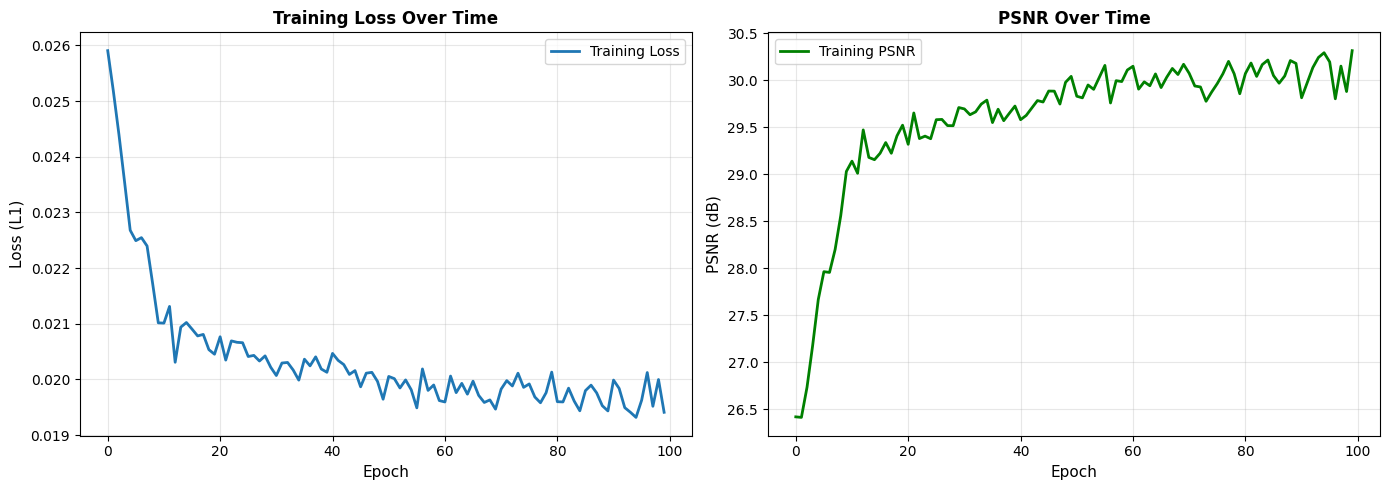

In [11]:
# Plot training curves
plot_training_curves(loss_hist_1, psnr_hist_1)
plt.show()


Evaluating on Hubble Deep Field...



Results for Hubble Deep Field:
  Bicubic PSNR: 26.91 dB
  ZSSR PSNR:    30.41 dB
  Improvement:  +3.50 dB



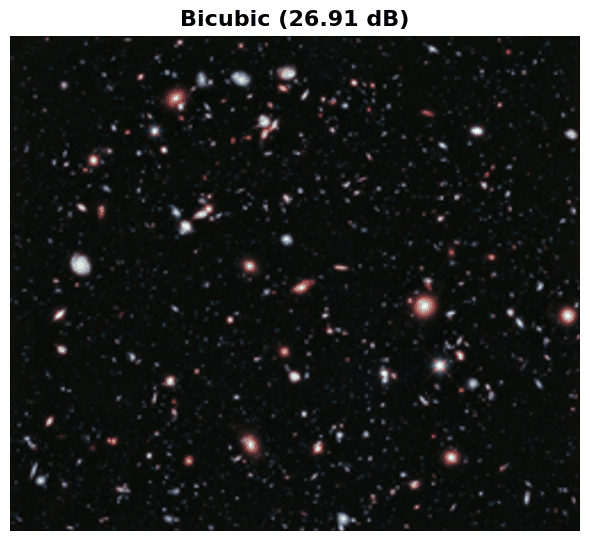
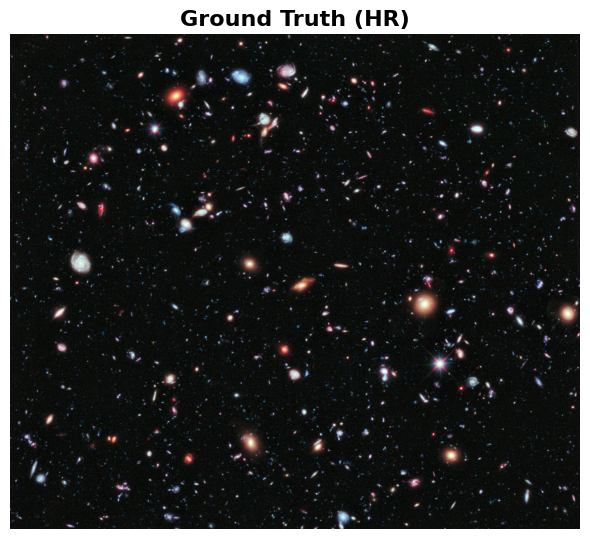

In [12]:
# Evaluate on Image 1
print(f"Evaluating on {img_name_1}...")
results_1 = evaluate_zssr(model_1, test_image_1, scale_factor=4, device=device)

print(f"\nResults for {img_name_1}:")
print(f"  Bicubic PSNR: {results_1['PSNR_Bicubic']:.2f} dB")
print(f"  ZSSR PSNR:    {results_1['PSNR_ZSSR']:.2f} dB")
print(f"  Improvement:  {results_1['PSNR_ZSSR'] - results_1['PSNR_Bicubic']:+.2f} dB")

# Full-size flickering comparison
visualize_results(results_1, title=img_name_1)

## Training on Image 2

In [13]:
# Prepare data for Image 2
img_name_2 = image_names[1]
test_image_2 = test_images[img_name_2]

dataset_2 = ZSSRDataset(
    test_image_2,
    scale_factor=scale_factor,
    crop_size=64,
    n_samples=100,
    augment=False
)

dataloader_2 = DataLoader(dataset_2, batch_size=4, shuffle=True)

# Initialize and train
model_2 = ZSSRNet(in_channels=3, n_channels=64, n_layers=8)

print(f"Training ZSSR on {img_name_2}...")
model_2, loss_hist_2, psnr_hist_2 = train_zssr(
    model_2,
    dataloader_2,
    scale_factor=scale_factor,
    num_epochs=100,
    learning_rate=0.001,
    device=device,
    verbose=True
)

print("Training complete!")

Training ZSSR on Rocket...


Epoch 10/100 | Loss: 0.016952 | PSNR: 28.80 dB


Epoch 20/100 | Loss: 0.011020 | PSNR: 31.99 dB


Epoch 30/100 | Loss: 0.014643 | PSNR: 29.66 dB


Epoch 40/100 | Loss: 0.014776 | PSNR: 30.14 dB


...

Epoch 60/100 | Loss: 0.015482 | PSNR: 29.68 dB


Epoch 70/100 | Loss: 0.014761 | PSNR: 30.04 dB


Epoch 80/100 | Loss: 0.013424 | PSNR: 29.58 dB


Epoch 90/100 | Loss: 0.013548 | PSNR: 30.12 dB


Epoch 100/100 | Loss: 0.013010 | PSNR: 30.28 dB
Training complete!


Evaluating on Rocket...



Results for Rocket:
  Bicubic PSNR: 27.14 dB
  ZSSR PSNR:    28.15 dB
  Improvement:  +1.01 dB



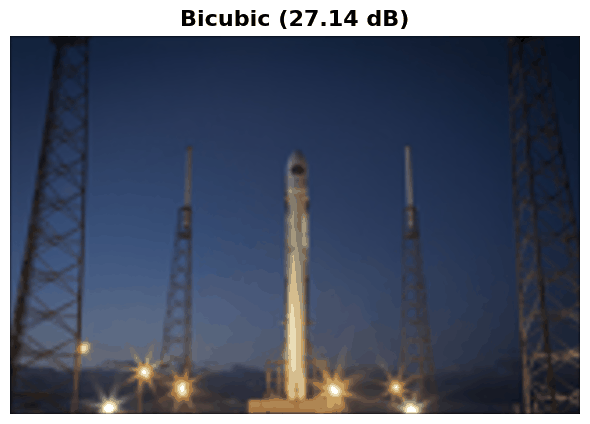
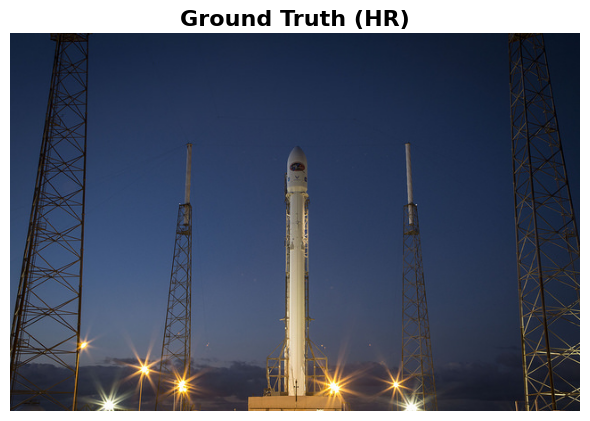

In [14]:
# Evaluate on Image 2
print(f"Evaluating on {img_name_2}...")
results_2 = evaluate_zssr(model_2, test_image_2, scale_factor=4, device=device)

print(f"\nResults for {img_name_2}:")
print(f"  Bicubic PSNR: {results_2['PSNR_Bicubic']:.2f} dB")
print(f"  ZSSR PSNR:    {results_2['PSNR_ZSSR']:.2f} dB")
print(f"  Improvement:  {results_2['PSNR_ZSSR'] - results_2['PSNR_Bicubic']:+.2f} dB")

# Full-size flickering comparison
visualize_results(results_2, title=img_name_2)

# Part 9: Comprehensive Analysis

## Summary of Results


In [15]:
# Analyze all results
results_list = [results_1, results_2]

psnr_improvements = analyze_results(results_list, image_names)


ZSSR ANALYSIS SUMMARY

Image: Hubble Deep Field
  Bicubic PSNR: 26.914 dB
  ZSSR PSNR:    30.411 dB
  Improvement:  +3.497 dB

Image: Rocket
  Bicubic PSNR: 27.141 dB
  ZSSR PSNR:    28.148 dB
  Improvement:  +1.007 dB

Average PSNR Improvement: +2.252 dB


*Write your analysis here: When does ZSSR work well and when does it struggle? Compare with traditional methods like bicubic upsampling.*

# Part 10: Bonus — Advanced Features & Extensions (up to 15 pts bonus)

Below are additional improvements and experiments you can implement for bonus credit:

### Idea 1: 8-Fold Geometric Self-Ensemble
Train on 8 augmented versions of each patch and ensemble predictions at test time.


In [16]:
# Example: Train with 8-fold augmentation
print("Training with 8-fold augmentation...")

dataset_augmented = ZSSRDataset(
    test_image_1,
    scale_factor=4,
    crop_size=64,
    n_samples=20,
    augment=True  # Enable 8-fold augmentation
)

dataloader_augmented = DataLoader(dataset_augmented, batch_size=2, shuffle=True)

model_augmented = ZSSRNet(in_channels=3, n_channels=64, n_layers=8)

print("Training with augmentation...")
model_augmented, loss_hist_aug, psnr_hist_aug = train_zssr(
    model_augmented,
    dataloader_augmented,
    scale_factor=4,
    num_epochs=30,
    learning_rate=0.001,
    device=device,
    verbose=True
)

# Evaluate with ensemble
results_aug = evaluate_zssr(model_augmented, test_image_1, scale_factor=4, device=device)
print(f"\nAugmented model PSNR: {results_aug['PSNR_ZSSR']:.2f} dB")
print(f"Original model PSNR:   {results_1['PSNR_ZSSR']:.2f} dB")
print(f"Improvement: {results_aug['PSNR_ZSSR'] - results_1['PSNR_ZSSR']:+.2f} dB")

Training with 8-fold augmentation...
Training with augmentation...


Epoch 10/30 | Loss: 0.024698 | PSNR: 26.45 dB


Epoch 20/30 | Loss: 0.022532 | PSNR: 28.09 dB


Epoch 30/30 | Loss: 0.022361 | PSNR: 28.10 dB



Augmented model PSNR: 28.81 dB
Original model PSNR:   30.41 dB
Improvement: -1.60 dB


### Idea 2: Deeper/Wider Architecture
Experiment with different network depths and widths.


In [17]:
# Test different architectures
architectures = [
    {'in_channels': 3, 'n_channels': 32, 'n_layers': 6, 'name': 'Shallow (32ch, 6L)'},
    {'in_channels': 3, 'n_channels': 64, 'n_layers': 8, 'name': 'Standard (64ch, 8L)'},
    {'in_channels': 3, 'n_channels': 128, 'n_layers': 12, 'name': 'Deep (128ch, 12L)'},
]

print("Architecture Comparison:")
print("-" * 60)

for arch in architectures:
    model_test = ZSSRNet(in_channels=arch['in_channels'], n_channels=arch['n_channels'], n_layers=arch['n_layers'])
    n_params = sum(p.numel() for p in model_test.parameters())
    print(f"{arch['name']:30s} | Parameters: {n_params:,}")

Architecture Comparison:
------------------------------------------------------------
Shallow (32ch, 6L)             | Parameters: 38,755
Standard (64ch, 8L)            | Parameters: 225,091
Deep (128ch, 12L)              | Parameters: 1,482,883


### Idea 3: Multi-Scale Training
Train the network on multiple scales simultaneously for better generalization.


In [18]:
def train_zssr_multiscale(
    model,
    image,
    scale_factors=[2],
    num_epochs=100,
    learning_rate=0.001,
    device='cpu',
    verbose=True
):
    """
    Train ZSSR on multiple scales.
    """
    model = model.to(device)
    criterion = nn.L1Loss()
    optimizer = Adam(model.parameters(), lr=learning_rate)
    
    print(f"Training on scales: {scale_factors}")
    
    for scale_idx, scale_factor in enumerate(scale_factors):
        print(f"\n--- Training on scale {scale_factor}x ---")
        
        dataset = ZSSRDataset(
            image,
            scale_factor=scale_factor,
            crop_size=64,
            n_samples=150,
            augment=False
        )
        dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
        
        for epoch in range(num_epochs):
            for batch in dataloader:
                hr = batch['HR'].to(device)
                lr = batch['LR'].to(device)
                
                optimizer.zero_grad()
                sr = model(lr, scale_factor=scale_factor,
                           target_size=(hr.shape[-2], hr.shape[-1]))
                
                # Ensure sr matches hr shape
                if sr.shape != hr.shape:
                    sr = resize_bicubic(sr, size=(hr.shape[-2], hr.shape[-1]))
                
                loss = criterion(sr, hr)
                loss.backward()
                optimizer.step()
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {loss.item():.6f}")
    
    return model

print("Multi-scale training function defined.")

Multi-scale training function defined.


# Submission Checklist

Before submitting, verify:
- [ ] All code cells executed with outputs visible
- [ ] Training curves (loss and PSNR) are plotted
- [ ] ZSSR vs Bicubic comparison images displayed
- [ ] Your `STUDENT_ID` is set correctly